In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

sns.set_theme(style="whitegrid")

In [21]:
df = pd.read_csv("bank_data.csv", sep=";")

print("Shape:", df.shape)
display(df.head())

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [22]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["y"].value_counts())
display(df["y"].value_counts(normalize=True) * 100)

Data types:


,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Missing values:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Duplicates: 0

Target distribution:


,count
y,
no,39922
yes,5289


,proportion
y,
no,88.30152
yes,11.69848


In [23]:
X = df.drop(columns="y")

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

binary_cols = [
    c for c in X.columns
    if X[c].nunique() == 2
]

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
print("Binary:", binary_cols)

Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Binary: ['default', 'housing', 'loan']


In [24]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())

display(df[num_cols].describe().T)


job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [25]:
df["y"] = df["y"].map({"no": 0, "yes": 1})
y = df["y"]

print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


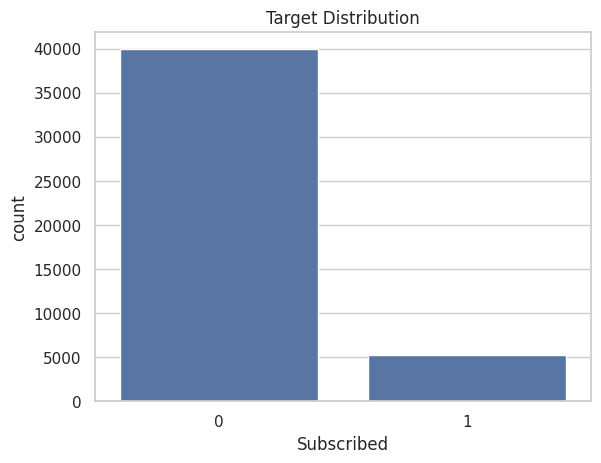

In [26]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Subscribed")
plt.show()

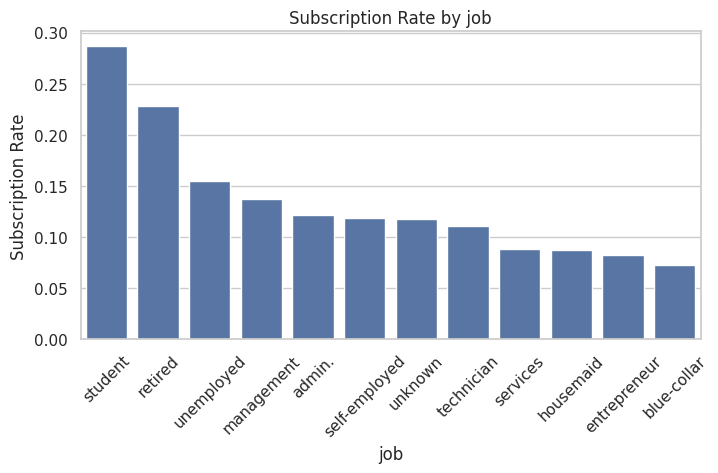

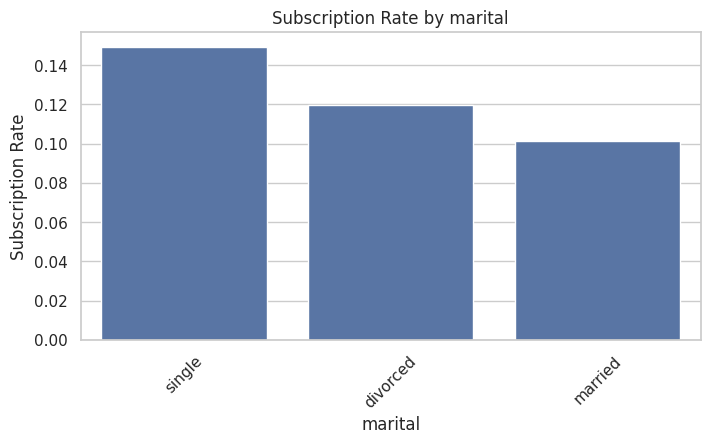

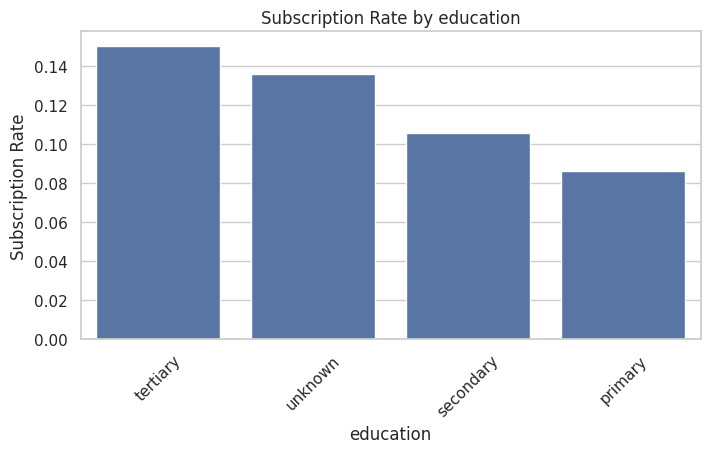

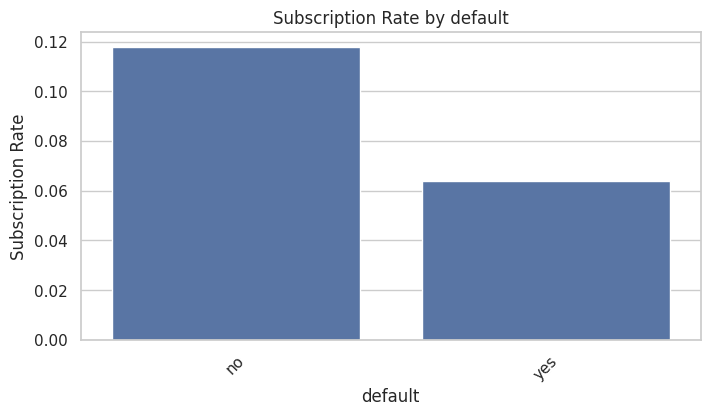

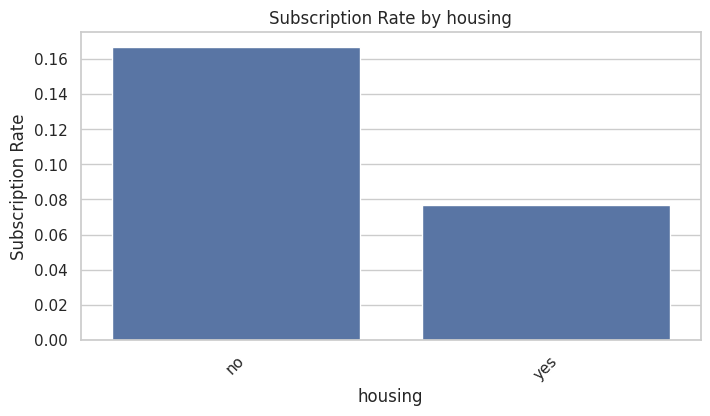

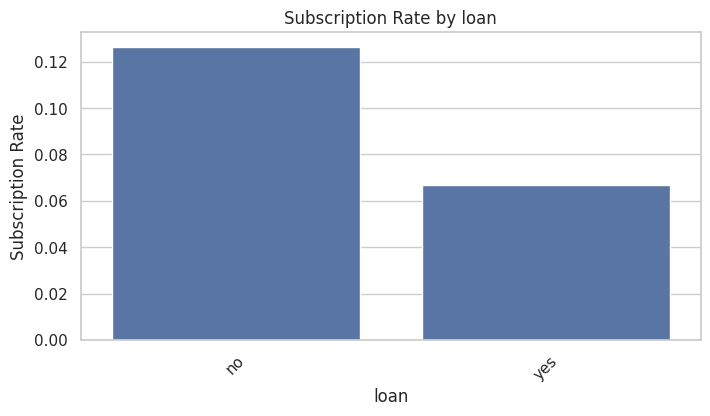

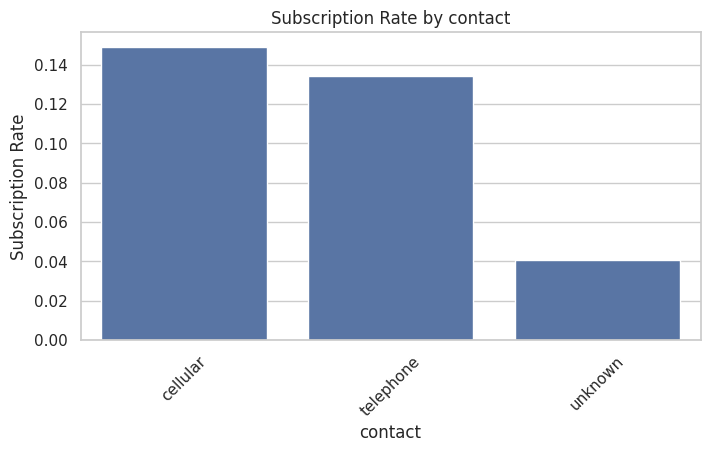

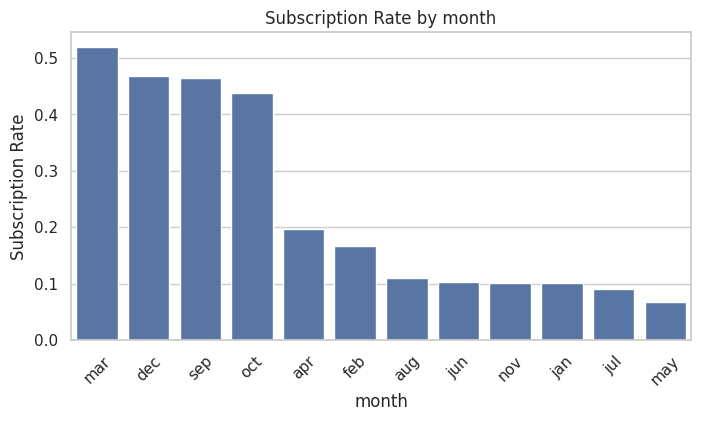

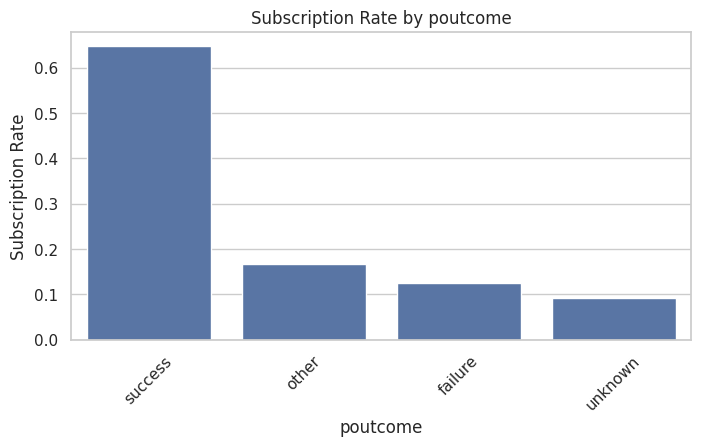

In [27]:
for col in cat_cols:
    rate = df.groupby(col)["y"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.index, y=rate.values)
    plt.title(f"Subscription Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Subscription Rate")
    plt.show()

In [28]:
display(
    df.groupby("y")[num_cols]
      .mean()
      .T
)

y,0,1
age,40.838986,41.670070
balance,1303.714969,1804.267915
day,15.892290,15.158253
duration,221.182806,537.294574
campaign,2.846350,2.141047
pdays,36.421372,68.702968
previous,0.502154,1.170354


In [29]:
exclude = [
    "contact",
    "day",
    "month",
    "duration",
    "campaign"
]

X = df.drop(columns=["y"] + exclude)

print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'pdays', 'previous', 'poutcome']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ), cat_cols)
])

In [32]:
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic.fit(X_train, y_train)

log_pred = logistic.predict(X_test)
log_prob = logistic.predict_proba(X_test)[:, 1]

In [33]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [34]:
def evaluate(name, y_true, pred, prob):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall   :", recall_score(y_true, pred))
    print("F1       :", f1_score(y_true, pred))
    print("ROC-AUC  :", roc_auc_score(y_true, prob))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, pred))

evaluate("Logistic Regression", y_test, log_pred, log_prob)
evaluate("Random Forest", y_test, rf_pred, rf_prob)


Logistic Regression
Accuracy : 0.8935087913303107
Precision: 0.6819923371647509
Recall   : 0.16824196597353497
F1       : 0.2699014404852161
ROC-AUC  : 0.7202434739995714

Confusion Matrix:
[[7902   83]
 [ 880  178]]

Random Forest
Accuracy : 0.8814552692690479
Precision: 0.48464912280701755
Recall   : 0.20888468809073724
F1       : 0.2919418758256275
ROC-AUC  : 0.6818028960255109

Confusion Matrix:
[[7750  235]
 [ 837  221]]


In [35]:
#comparision
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.893509,0.681992,0.168242,0.269901,0.720243
1,Random Forest,0.881455,0.484649,0.208885,0.291942,0.681803


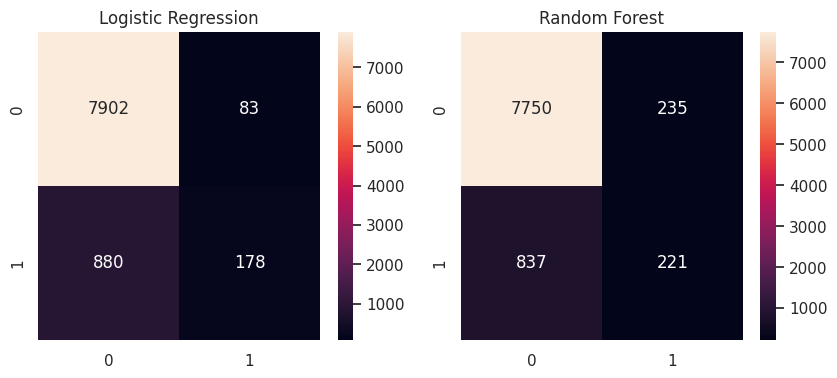

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True, fmt="d", ax=ax[0]
)
ax[0].set_title("Logistic Regression")

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True, fmt="d", ax=ax[1]
)
ax[1].set_title("Random Forest")

plt.show()

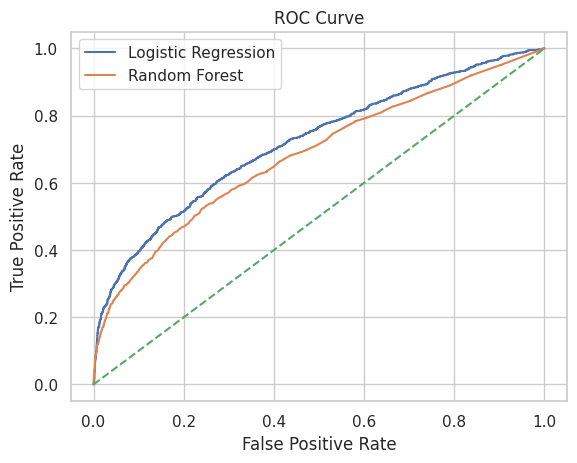

In [37]:
fpr1, tpr1, _ = roc_curve(y_test, log_prob)
fpr2, tpr2, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr1, tpr1, label="Logistic Regression")
plt.plot(fpr2, tpr2, label="Random Forest")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [38]:
if f1_score(y_test, rf_pred) > f1_score(y_test, log_pred):
    final_model = rf
    final_name = "Random Forest"
else:
    final_model = logistic
    final_name = "Logistic Regression"

print("Final model:", final_name)

Final model: Random Forest


In [39]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_model.predict(X_test)
).ravel()

print("False Positives:", fp)
print("False Negatives:", fn)

print("""
False Positive: predicted subscription but customer did not subscribe.
Business impact: unnecessary campaign/contact cost.

False Negative: predicted no subscription but customer subscribed.
Business impact: missed potential customer.

The preferred error depends on campaign cost and the value of reaching
potential subscribers.
""")

False Positives: 235
False Negatives: 837

False Positive: predicted subscription but customer did not subscribe.
Business impact: unnecessary campaign/contact cost.

False Negative: predicted no subscription but customer subscribed.
Business impact: missed potential customer.

The preferred error depends on campaign cost and the value of reaching
potential subscribers.



In [40]:
sample = X_test.head(5)

pred = final_model.predict(sample)
prob = final_model.predict_proba(sample)[:, 1]

sample_results = sample.copy()
sample_results["prediction"] = np.where(pred == 1, "yes", "no")
sample_results["probability"] = prob.round(3)

display(sample_results)

,age,job,marital,education,default,balance,housing,loan,pdays,previous,poutcome,prediction,probability
1392,40,blue-collar,married,primary,no,640,yes,yes,-1,0,unknown,no,0.013
7518,44,technician,married,secondary,no,378,yes,no,-1,0,unknown,no,0.003
12007,31,services,married,secondary,no,356,yes,no,-1,0,unknown,no,0.000
5536,36,blue-collar,married,primary,no,655,yes,no,-1,0,unknown,no,0.050
29816,34,services,single,secondary,no,1921,yes,no,-1,0,unknown,no,0.007


In [41]:
features = logistic.named_steps["preprocessor"].get_feature_names_out()
coef = logistic.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": features,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

display(importance.head(10))
display(importance.tail(10))

,feature,coefficient
24,cat__poutcome_success,2.261100
8,cat__job_retired,0.508079
11,cat__job_student,0.423676
18,cat__education_tertiary,0.365462
23,cat__poutcome_other,0.257339
17,cat__education_secondary,0.165396
16,cat__marital_single,0.161767
19,cat__education_unknown,0.138571
1,num__balance,0.071574
13,cat__job_unemployed,0.065097


,feature,coefficient
10,cat__job_services,-0.210670
9,cat__job_self-employed,-0.239367
14,cat__job_unknown,-0.263150
4,cat__job_blue-collar,-0.272569
25,cat__poutcome_unknown,-0.292852
5,cat__job_entrepreneur,-0.328236
20,cat__default_yes,-0.370077
22,cat__loan_yes,-0.420415
6,cat__job_housemaid,-0.451446
21,cat__housing_yes,-0.692665


In [42]:
print("""
Limitations:
1. The model identifies predictive associations, not causal relationships.
2. Accuracy alone is insufficient because the target is imbalanced.
3. The test set is a single held-out sample.
4. The default 0.5 classification threshold may not be optimal for business costs.
5. Excluding duration, campaign, contact, day and month can reduce predictive performance.
""")


Limitations:
1. The model identifies predictive associations, not causal relationships.
2. Accuracy alone is insufficient because the target is imbalanced.
3. The test set is a single held-out sample.
4. The default 0.5 classification threshold may not be optimal for business costs.
5. Excluding duration, campaign, contact, day and month can reduce predictive performance.

